In [21]:
import pandas as pd
df=pd.read_csv('simulated_agent_5k.csv')
print(df.head())

   Trial  Block Conflict Trial_Type  Cue_Valence  Optimal_Action  \
0      1  B1_MC       PC        NAL           -1               0   
1      2  B1_MC       PI         NW            1               0   
2      3  B1_MC       PI         NW            1               0   
3      4  B1_MC       PC         GW            1               1   
4      5  B1_MC       PC         GW            1               1   

   Agent_Choice  Agent_Reward  Correct  
0           1.0          -1.0        0  
1           0.0           1.0        1  
2           0.0           1.0        1  
3           0.0           0.0        0  
4           1.0           1.0        1  


In [14]:
## DIRECT INFERENCE
# print(df)
def direct_inference(df,length):
    results=[]
    for i in range(0,len(df),length):
        window=df.iloc[i:i+length]
        # get pc and pi for the specified widow
        pc_trials=window[window['Conflict'] == 'PC']
        pc_acc=pc_trials['Correct'].mean()
        pi_trials=window[window['Conflict'] == 'PI']
        pi_acc=pi_trials['Correct'].mean()
        pcpi_diff= pc_acc-pi_acc
        inference=str()
        # inferring
        if pcpi_diff > 0.7:
            inference='Low conflict'
        elif pcpi_diff < 0.3:
            inference='High conflict'
        else:
            inference='Med conflict'
        results.append({
            'start':i,
            'end' :i+length,
            'pc-pi diff':pcpi_diff,
            'pc_acc':pc_acc,
            'pi_acc':pi_acc,
            'inference': inference,
            'true_block': window['Block'].iloc[0]
        })
    return pd.DataFrame(results)

x=direct_inference(df,125)
print(x)

     start    end  pc-pi diff    pc_acc    pi_acc      inference true_block
0        0    125    0.214700  0.849315  0.634615  High conflict      B1_MC
1      125    250    0.284591  0.867925  0.583333  High conflict      B1_MC
2      250    375    0.113672  0.878378  0.764706  High conflict      B1_MC
3      375    500    0.275474  0.920635  0.645161  High conflict      B1_MC
4      500    625    0.153251  0.947368  0.794118  High conflict      B1_MC
..     ...    ...         ...       ...       ...            ...        ...
155  19375  19500    0.233477  0.854167  0.620690  High conflict      B4_LC
156  19500  19625    0.217054  0.883721  0.666667  High conflict      B4_LC
157  19625  19750    0.269489  0.956989  0.687500  High conflict      B4_LC
158  19750  19875    0.088849  0.883721  0.794872  High conflict      B4_LC
159  19875  20000    0.253479  0.885057  0.631579  High conflict      B4_LC

[160 rows x 7 columns]


In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

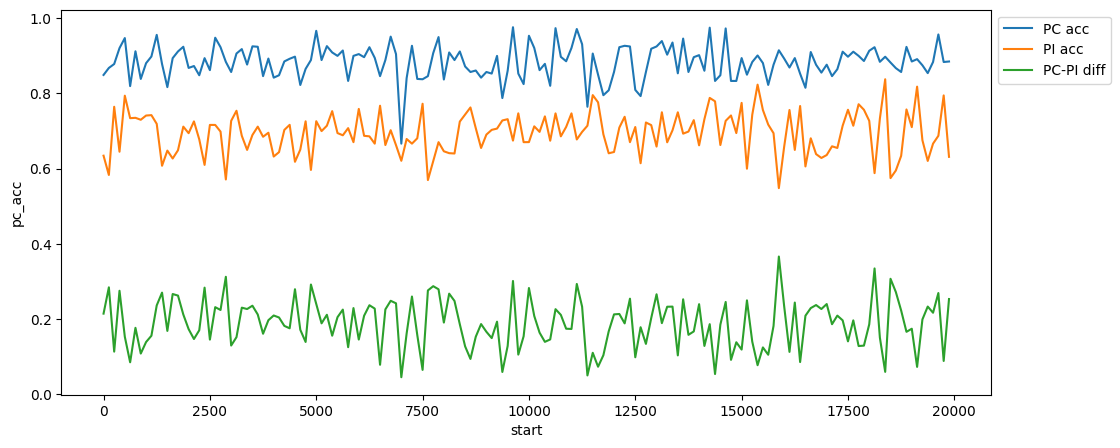

<Figure size 640x480 with 0 Axes>

In [16]:
plt.figure(figsize=(12, 5))
sns.lineplot(data=x, x='start', y='pc_acc', label='PC acc')
sns.lineplot(data=x, x='start', y='pi_acc', label='PI acc')
sns.lineplot(data=x, x='start', y='pc-pi diff', label='PC-PI diff')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.show()
plt.savefig('accuracy_trends.png', dpi=150, bbox_inches='tight')

In [23]:
obs_map = {
    (0, -1): 0,
    (0,  0): 1,
    (0,  1): 2,
    (1, -1): 3,
    (1,  0): 4,
    (1,  1): 5,
}

df['choice_reward'] = list(zip(df['Agent_Choice'].astype(int), df['Agent_Reward'].astype(int)))
df['obs'] = df['choice_reward'].map(obs_map)
print(df['obs'].head(10))


0    3
1    2
2    2
3    1
4    5
5    5
6    1
7    3
8    3
9    1
Name: obs, dtype: int64


In [24]:
from hmmlearn import hmm
import numpy as np

# prepare observation sequence — hmmlearn needs a 2D array
obs_seq = df['obs'].values.reshape(-1, 1)

# fit HMM with 3 hidden states
model = hmm.CategoricalHMM(n_components=3, n_iter=100, random_state=42)
model.fit(obs_seq)

,n_components,3
,n_features,np.int64(6)
,random_state,RandomState(M...0x7F215BA8A840
,n_iter,100
,startprob_prior,1.0
,transmat_prior,1.0
,emissionprob_prior,1.0
,algorithm,'viterbi'
,tol,0.01
,verbose,False
,params,'ste'


In [35]:
# Model accuracy per block
from sklearn.metrics import classification_report

# map hmm states to block labels based on what we observed
state_to_block = {0: 'LC', 1: 'LC', 2: 'HC'}
df['hmm_label'] = df['hmm_state'].map(state_to_block)

# true labels — simplify to 3 classes
block_to_label = {
    'B1_MC': 'MC',
    'B2_HC1': 'HC',
    'B3_HC2': 'HC',
    'B4_LC': 'LC'
}
df['true_label'] = df['Block'].map(block_to_label)

print(classification_report(df['true_label'], df['hmm_label']))

              precision    recall  f1-score   support

          HC       0.82      1.00      0.90     10000
          LC       0.63      1.00      0.78      5000
          MC       0.00      0.00      0.00      5000

    accuracy                           0.75     20000
   macro avg       0.49      0.67      0.56     20000
weighted avg       0.57      0.75      0.65     20000



/home/aswin/rl_projects/rl_algos/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/aswin/rl_projects/rl_algos/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/aswin/rl_projects/rl_algos/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier,

In [34]:
print("Transition matrix:")
print(model.transmat_.round(3))

print("\nEmission probabilities:")
print(model.emissionprob_.round(3))

print("\nInitial state probabilities:")
print(model.startprob_.round(3))

hidden_states = model.predict(obs_seq)
df['hmm_state'] = hidden_states
print(df.groupby(['Block', 'hmm_state']).size().unstack(fill_value=0))

Transition matrix:
[[0.003 0.997 0.   ]
 [0.976 0.021 0.003]
 [0.001 0.    0.999]]

Emission probabilities:
[[0.026 0.303 0.084 0.066 0.241 0.281]
 [0.028 0.268 0.102 0.045 0.236 0.322]
 [0.047 0.141 0.184 0.028 0.45  0.15 ]]

Initial state probabilities:
[1. 0. 0.]
hmm_state     0     1     2
Block                      
B1_MC      1437  1438  2125
B2_HC1        0     0  5000
B3_HC2        0     0  5000
B4_LC      2498  2501     1


# map hmm states to block labels based on what we observed
# state_to_block = [0: 'LC', 1: 'LC', 2: 'HC']
## Categorical hmm: 3 hidden states, observations(agent_choice, agent_reward)
- Perfect classification of HC1 and HC2

- States 0 and 1 (low and medium conflicts), couldnt be separated from each other.
- Both have emission probability being the highest for GW.

- Since MC and LC differ only in proportion of PC vs PI trials. Their average reward patterns are too similar ot distinsguih with choice reward alone

- Raw behavior can easily separate HC and LC/MC.

- So we are adding cue valence information into our HMM.


In [33]:
## Adding cue valence to this
print(df['Cue_Valence'].unique())
print(df['Agent_Choice'].unique())
print(df['Agent_Reward'].unique())

[-1  1]
[1. 0.]
[-1.  1.  0.]


In [41]:
df['state'] = hidden_states

print(pd.crosstab(
    df['state'],
    df['Conflict'],
    margins=True
))

Conflict    PC     PI    All
state                       
0         2559   1376   3935
1         2497   1442   3939
2         3944   8182  12126
All       9000  11000  20000


In [44]:
df3=df.copy()
df3['obs_tuple'] = list(zip(
    df3['Agent_Choice'].astype(int),
    df3['Agent_Reward'].astype(int),
    df3['Cue_Valence'].astype(int)
))

# create observation tuples
df3['obs_tuple'] = list(zip(
    df3['Agent_Choice'].astype(int),
    df3['Agent_Reward'].astype(int),
    df3['Cue_Valence'].astype(int)
))

# get all unique observation types
unique_obs = df3['obs_tuple'].unique()

# assign each observation type an integer
obs_map3 = {}

for i, obs in enumerate(unique_obs):
    obs_map3[obs] = i

# convert tuples to integers
df3['obs'] = df3['obs_tuple'].map(obs_map3)


In [46]:
obs_seq3 = df3['obs'].values.reshape(-1, 1)

model3 = hmm.CategoricalHMM(
    n_components=3,
    n_iter=100,
    random_state=42
)

model3.fit(obs_seq3)

,n_components,3
,n_features,np.int64(8)
,random_state,RandomState(M...0x7F215B3E2240
,n_iter,100
,startprob_prior,1.0
,transmat_prior,1.0
,emissionprob_prior,1.0
,algorithm,'viterbi'
,tol,0.01
,verbose,False
,params,'ste'


In [48]:
hidden_states3 = model3.predict(obs_seq3)

df3['hidden_state'] = hidden_states3

In [50]:
print(df3['hidden_state'].value_counts().sort_index())

hidden_state
0    5918
1    5922
2    8160
Name: count, dtype: int64


In [53]:
pd.crosstab(
    df3['hidden_state'],
    df3['Conflict'],
    margins=True
)
print(model3.emissionprob_)
print(model3.transmat_)

[[0.02879052 0.20419774 0.0143814  0.15070374 0.13754259 0.14258968
  0.03892559 0.28286875]
 [0.02670161 0.16371793 0.00674652 0.14971378 0.12276631 0.17384721
  0.0551791  0.30132754]
 [0.05527759 0.09296602 0.01733481 0.30124178 0.26753612 0.08428259
  0.02692117 0.15443992]]
[[2.15732994e-03 9.97839836e-01 2.83439694e-06]
 [9.78139651e-01 1.96284825e-02 2.23186604e-03]
 [1.15568059e-03 4.87234546e-04 9.98357085e-01]]
